# Gradient Descent
It is a first order iterative optimisation(attaining best performance) algo for finding local minima of a differentiable fn at all pts.

> Types of G.D
1. Batch G.D
2. SGD
3. Mini Batch GD

> Intuition behind G.D

<img src='img1.png'></img>
- To know in which direction we need to move
- Select a random min pt
- Find the slope of fn(graph/line) at that pt
- If negative slope -> increment in b val 
- If positive slope -> decrement in b val 
- Formula : Bnew = (B)old - slope
- In this formula, there is problem that b shuffle in b/w parabolic curve and getting accurate local minima is difficult
- Updated Formula : Bnew = (B)old - N*slope
- Here N is learning rate which is generally equal to 0.01, B is intercept, N*slope is called step size

> When to stop?
1. When (B)old - Bnew <= 0.001 or both becomes nearly same
2. Iteration limit(epochs)

> Mathematical formulatn:

<img src='img2.png'></img>
<img src='img3.png'></img>
- Assumptn : to calculate we let or find m val using OLS and now only changing b(intercept) val for finding G.D
- the highlighted box become new eqn and change the val of m to get new val of Bnew
- How to find slope -> differentiate loss fn wrt b

In [16]:
from sklearn.datasets import make_regression
import numpy as np

In [17]:
X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)

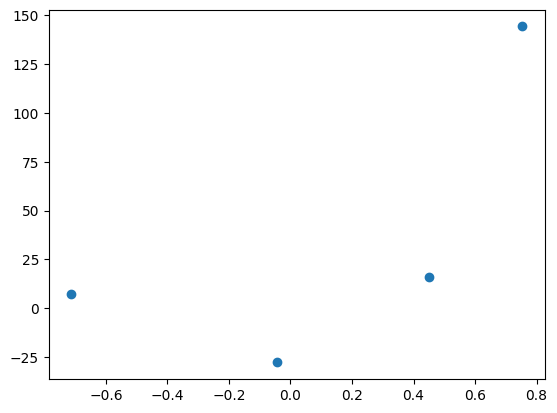

In [18]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [19]:
# Lets apply OLS for getting slope and intercept val
from sklearn.linear_model import LinearRegression

In [20]:
reg = LinearRegression()
reg.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
reg.coef_

array([78.35063668])

In [22]:
reg.intercept_

np.float64(26.15963284313262)

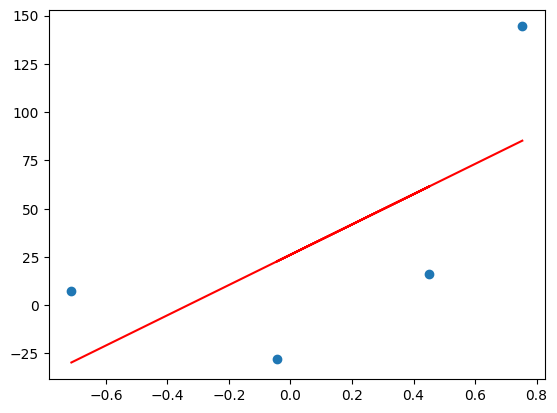

In [23]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

In [24]:
# Lets apply Gradient Descent assuming slope is constant m = 78.35
# and let's assume the starting value for intercept b = 0
y_pred = ((78.35 * X) + 100).reshape(4)

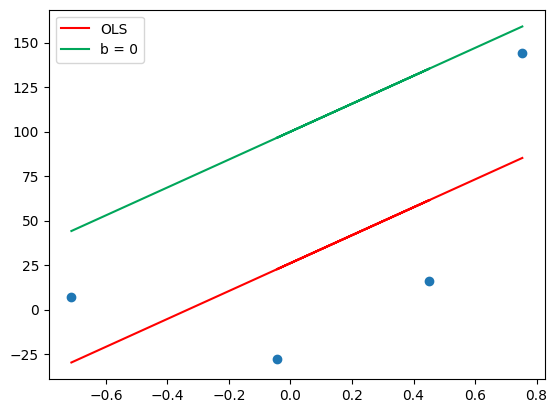

In [25]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='#00a65a',label='b = 0')
plt.legend()
plt.show()

In [26]:
m = 78.35
b = 100

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(590.7223659179078)

In [27]:
# Lets take learning rate = 0.1
lr = 0.1

step_size = loss_slope*lr
step_size

np.float64(59.072236591790784)

In [28]:
# Calculating the new intercept
b = b - step_size
b

np.float64(40.927763408209216)

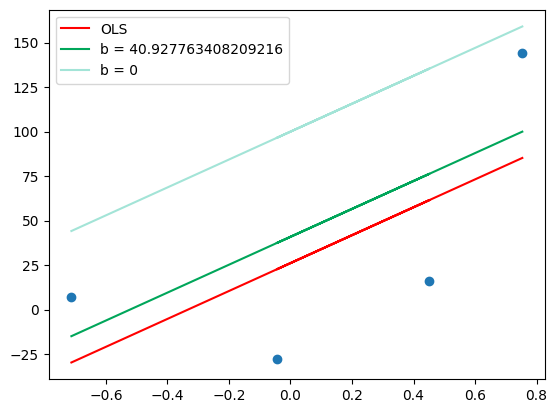

In [29]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [30]:
# Iteration 2
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(118.14447318358157)

In [31]:
step_size = loss_slope*lr
step_size

np.float64(11.814447318358157)

In [32]:
b = b - step_size
b

np.float64(29.11331608985106)

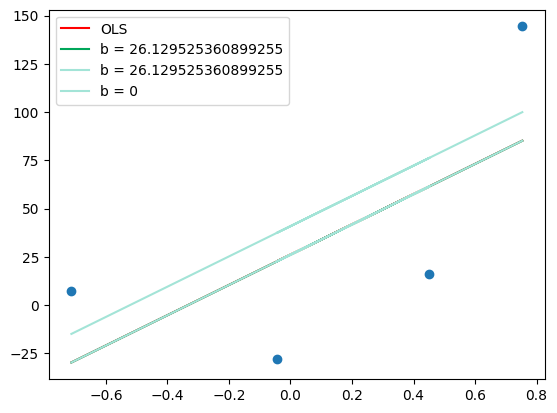

In [39]:
y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

In [34]:
# Iteration 3
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(23.62889463671634)

In [35]:
step_size = loss_slope*lr
step_size

np.float64(2.362889463671634)

In [36]:
b = b - step_size
b

np.float64(26.750426626179426)

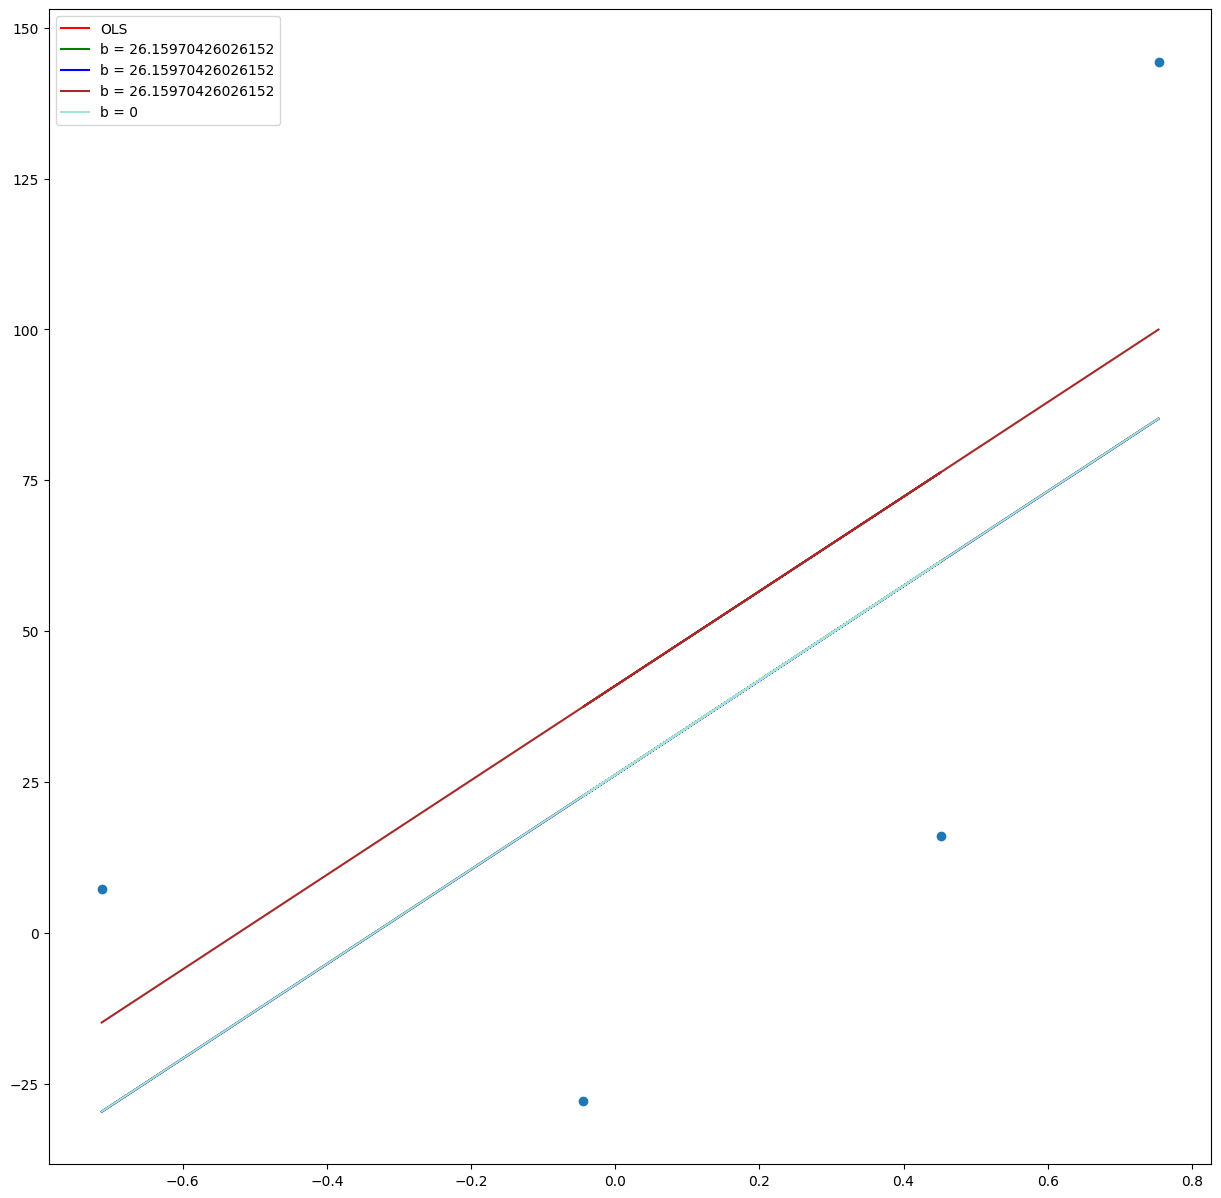

In [42]:
y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')
plt.legend()
plt.show()

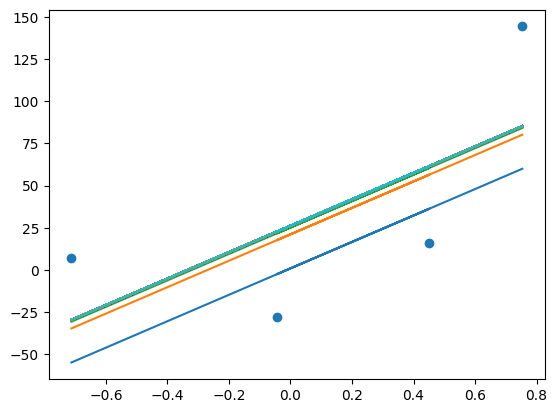

In [40]:
b = -100
m = 78.35
lr = 0.1

epochs = 100

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (lr * loss_slope)

  y_pred = m * X + b

  plt.plot(X,y_pred)

plt.scatter(X,y)